In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import collections
import xarray as xr
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime
import cf_xarray as cf
import cftime

import regionmask
import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo
import seaborn as sns

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

In [2]:
def lonFlip(var):
    """
    Convert longitude values from the -180:180 to 0:360 convention or vice versa.

    ** Works for both global data due to auto-detection of longitude convention **
    More efficient than rolling: only relabels coordinates + sorts.

    Parameters
    ----------
    var : xr.DataArray or xr.Dataset
    """

    #=== Get var info
    lon_name=var.cf.axes["X"][0]    # find longitude axis and store coordinate name
    lon=var[lon_name]               # extract lon array

    #=== Detect current longitude convention and wrap values
    if lon.min() < 0:
        # -180:180 -> 0:360
        new_lon = lon % 360
        target_range = "0:360"
    else:
        # 0:360 -> -180:180
        new_lon = ((lon + 180) % 360) - 180
        target_range = "-180:180"

    #=== Assign and sort
    var = var.assign_coords({lon_name: new_lon}).sortby(lon_name)

    #=== Add history
    timestamp = datetime.now().strftime("%B %d, %Y, %r")
    hist_message = f"wrapped longitudes to {target_range} on {timestamp}"
    if isinstance(var, xr.DataArray):
        var.attrs["history"] = hist_message
    else: # Dataset
        var.attrs["history"] = var.attrs.get("history","") + "\n" + hist_message

    return var

In [47]:
def jas_seasonal_mean(ds):
    """
    Calculate seasonal mean accounting for varying month lengths
    ** assumes no leap **
    """    
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_weighted_mean = (jas * weights).sum(dim='time') / weights.sum(dim='time')
    return jas_weighted_mean

def jas_yearly_mean(ds):
    """
    Calculate jas seasonal mean for each year, accounting for varying month lengths
    ** assumes no leap **
    """ 
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_yearly_weighted_mean = ((jas * weights).groupby('time.year').sum(dim='time') / weights.groupby('time.year').sum(dim='time'))
    return jas_yearly_weighted_mean

def rotated_box(lon0, lat0, width, height, angle_deg):
    angle = np.deg2rad(angle_deg)

    # Half sizes
    dx = width / 2
    dy = height / 2

    # Corners relative to center
    corners = np.array([
        [-dx, -dy],
        [ dx, -dy],
        [ dx,  dy],
        [-dx,  dy]
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    rotated = corners @ R.T
    rotated[:, 0] += lon0
    rotated[:, 1] += lat0

    return rotated

def regional_weighted_mean(da, region_name):

    mask3d = regions.mask_3D(da)
    region_index = regions.names.index(region_name)
    masked = da.where(mask3d.sel(region=region_index))
    weights = np.cos(np.deg2rad(da.lat))
    
    return masked.weighted(weights).mean(("lat", "lon"))

In [10]:
### +++ DATA PATHS +++ ###

# product keys
keys=['obs','flor-pi','flor-2xco2']
obs_prods=['imerg']
cases=['pi','2xco2']

# store file paths in dictionary
dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar' # top level data directory
opath='/home/dmkumar/JupyterLinks/notebooks/topo_nam'
files={ 'obs':    {}, 
        'ctrl':   { 'pi':{}, '2xco2':{} },
        'hitopo': { 'pi':{}, '2xco2':{} } }

for key in ['obs']:
    for i,run in enumerate(obs_prods):
        files[key][run] = f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc' 

for key in ['ctrl','hitopo']:
    varn='precip'
    for i,case in enumerate(cases):
        if case=='pi':
            files[key][case] = f'{dpath0}/FLOR/{key}/{case}/flor.{key}.{varn}.monthly.nc'
        elif case=='2xco2':
            files[key][case] = f'{dpath0}/FLOR/{key}/{case}/flor.{key}.{case}.{varn}.monthly.nc'

for key in ['topo']:
    files[key] = {}
    files[key]['etopo'] = f'{dpath0}/topo_files/obs.etopo5.zsurf.nc'
    files[key]['ctrl'] = f'{dpath0}/topo_files/flor.ctrl.zsurf.nc'
    files[key]['hicam'] = f'{dpath0}/topo_files/flor.cam.zsurf.nc'
    files[key]['hitopo'] = f'{dpath0}/topo_files/flor.hitopo.zsurf.nc'

In [8]:
## ORGANIZE DATA AND CALCULATE CLIMATOLOGIES

# lat lon bounds
latmin = 10
latmax = 80
lonmin = -160
lonmax = -60
# want model time-series to have the same length
n_years=30
t_idx = -1 * n_years * 365 # number of time steps to keep in days
n_keep=-1*(n_years*12) # number of time steps to keep in months

# initialize dictionaries
dat={ 'obs':    {}, 
      'ctrl':   { 'pi':{}, '2xco2':{} },
      'hitopo': { 'pi':{}, '2xco2':{} } }
jas_mean={ 'obs':    {}, 
           'ctrl':   { 'pi':{}, '2xco2':{} },
           'hitopo': { 'pi':{}, '2xco2':{} } }
ann_jas_mean={ 'obs':    {}, 
               'ctrl':   { 'pi':{}, '2xco2':{} },
               'hitopo': { 'pi':{}, '2xco2':{} } }


print('Working on...')
    
for key in ['obs']:
    print(f'{key}')
    for run in obs_prods:
        ds = xr.open_dataset(files[key][run], chunks={}).precipitation.sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax)) * 24 # convert from mm/hr to mm/day
        ds = ds.transpose('time','lat','lon')
        ds.attrs['units'] = 'mm/day'
        ds.attrs['Units'] = 'mm/day'
        dat[key][run] = ds
        del ds
        # calcluate time means
        jas_mean[key][run] = jas_seasonal_mean(dat[key][run])
        ann_jas_mean[key][run] = jas_yearly_mean(dat[key][run])
        
for key in ['ctrl','hitopo']:
    print(f'{key}')
    for case in cases:
        # open diag files
        ds = xr.open_dataset(files[key][case]).precip[n_keep:-1,:,:].rename({'grid_xt':'lon','grid_yt':'lat'}) * 86400 # convert from mm/s to mm/day
        ds_flip = lonFlip(ds)
        dat[key][case] = ds_flip.sel(lon=slice(lonmin,lonmax), lat=slice(latmin,latmax))
        del ds
        del ds_flip
        # calcluate time means
        jas_mean[key][case] = jas_seasonal_mean(dat[key][case])
        ann_jas_mean[key][case] = jas_yearly_mean(dat[key][case])


topo = {}
for key in ['topo']:
    for case in ['ctrl', 'hicam', 'hitopo']:
        ds = xr.open_dataset(files[key][case]).ZSURF.rename({'GRID_XT':'lon', 'GRID_YT':'lat'})
        ds_flip = lonFlip(ds)
        topo[case] = ds_flip.where(ds_flip>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
        del ds
        del ds_flip
        

print('Done.')


Working on...
obs
ctrl
hitopo
Done.


In [70]:
## COMPARING 2xCO2 MODEL RUNS TO MODEL PI.

# initialize dictionaries
future_diff = { 'ctrl':{}, 'hitopo':{} }
future_diff_mask = { 'ctrl':{}, 'hitopo':{} }
future_ptvals = { 'ctrl':{}, 'hitopo':{} }

print('Significance testing for:')
for key in ['ctrl','hitopo']:
    print(f'{key}')
    diff_, diff_mask_, ptvals_ = sigtest(ann_jas_mean[key]['2xco2'], ann_jas_mean[key]['pi'],
                                         jas_mean[key]['2xco2'], jas_mean[key]['pi'])
    future_diff[key] = diff_
    future_diff_mask[key] = diff_mask_
    future_ptvals[key] = ptvals_
print('Done.')


Significance testing for:
ctrl
hitopo
Done.


In [48]:
# Define rectangular polygons (counter-clockwise)

domains = ['core','north']
coords_map = { d: [] for d in domains}
coords_calc = { d: [] for d in domains}

coords_map['core'] = rotated_box(-107, 25, 4.5, 10, angle_deg=35)
coords_calc['core'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['core'] ]

coords_map['north'] = rotated_box(-110.5, 32.5, 8, 6, angle_deg=0)
coords_calc['north'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['north'] ]

regions = regionmask.Regions(
    outlines=[coords_calc['core'], coords_calc['north']],
    names=["core", "north"],
    abbrevs=["core", "north"]
)

## FIGS: 2xCO2$-$PI absolute change in JAS precipitation

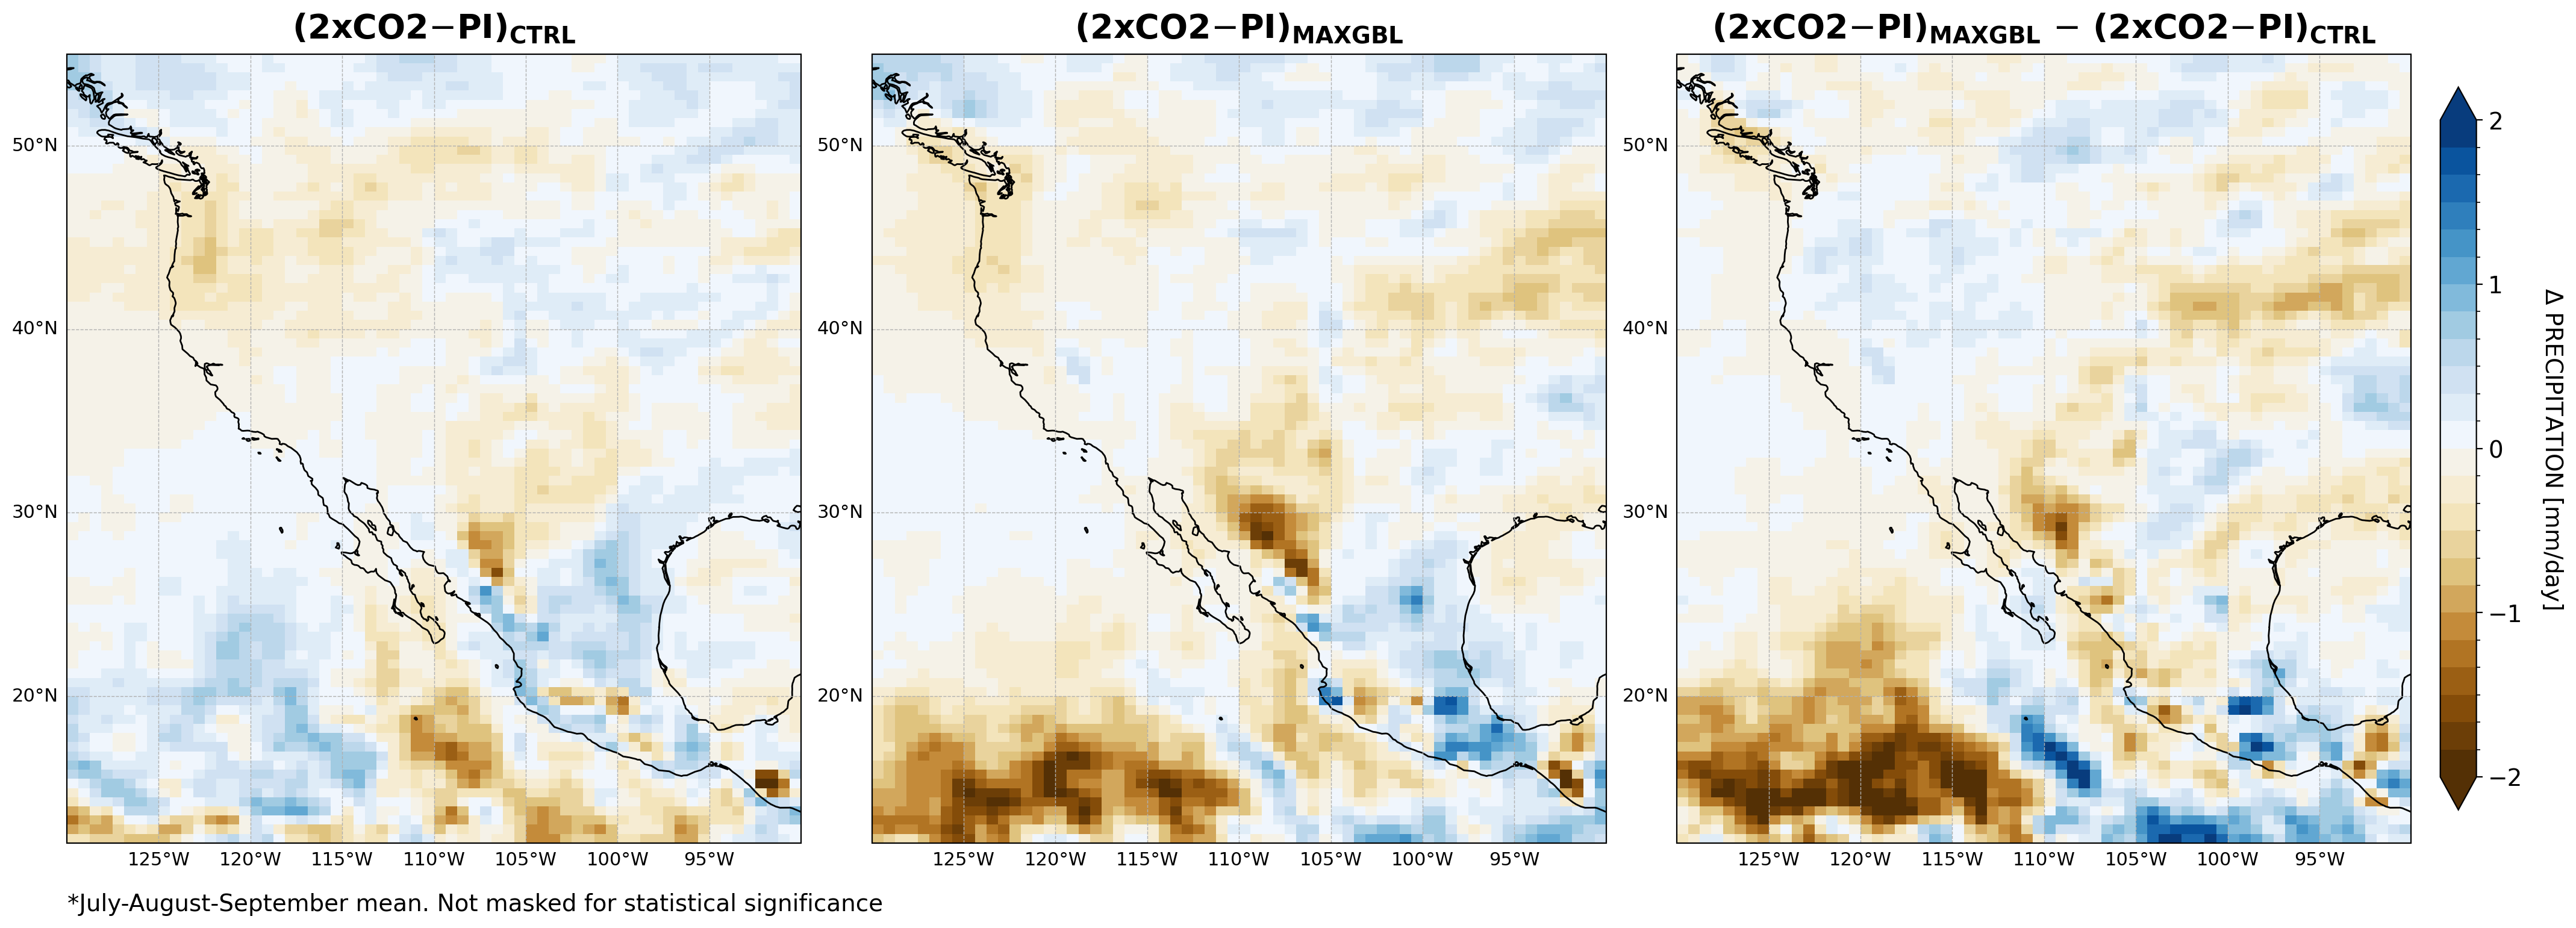

In [20]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':16, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
text_kw2={'color':'k', 'weight':'normal', 'size':14, 'horizontalalignment':'left', 'verticalalignment':'bottom'}
text_kw3={'color':'k', 'weight':'bold', 'size':20, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
titles=([r'(2xCO2$-$PI)$\mathbf{_{CTRL}}$',
         r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$',
         r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$ $-$ (2xCO2$-$PI)$\mathbf{_{CTRL}}$'])
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-2
dvmax=2
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[-130,-90,12,55]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,7.5), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'JAS Precipitation [FLOR]', **text_kw)
fig.text(0.025,-0.0175,
         '*July-August-September mean. '
         'Not masked for statistical significance', **text_kw2)

future_diff_diff = future_diff['hitopo'] - future_diff['ctrl']
lon=future_diff_diff.lon
lat=future_diff_diff.lat

ax[0].pcolormesh(lon, lat, future_diff['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)
ax[1].pcolormesh(lon, lat, future_diff['hitopo'], cmap=dcmap, norm=dnorm, transform=trans)
cf2=ax[2].pcolormesh(lon, lat, future_diff_diff, cmap=dcmap, norm=dnorm, transform=trans) 

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-110, 55.5, titles[i], **text_kw3)
    # map properties
    ax.coastlines(color='k')
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':11}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':11}
    
cax=fig.add_axes([1.01, .1, 0.015, 0.8])
cbar=fig.colorbar(cf2, ticks=[-2,-1,0,1,2], orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ PRECIPITATION [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/precip.flor.2xco2.{season}.png', transparent=False, bbox_inches='tight')

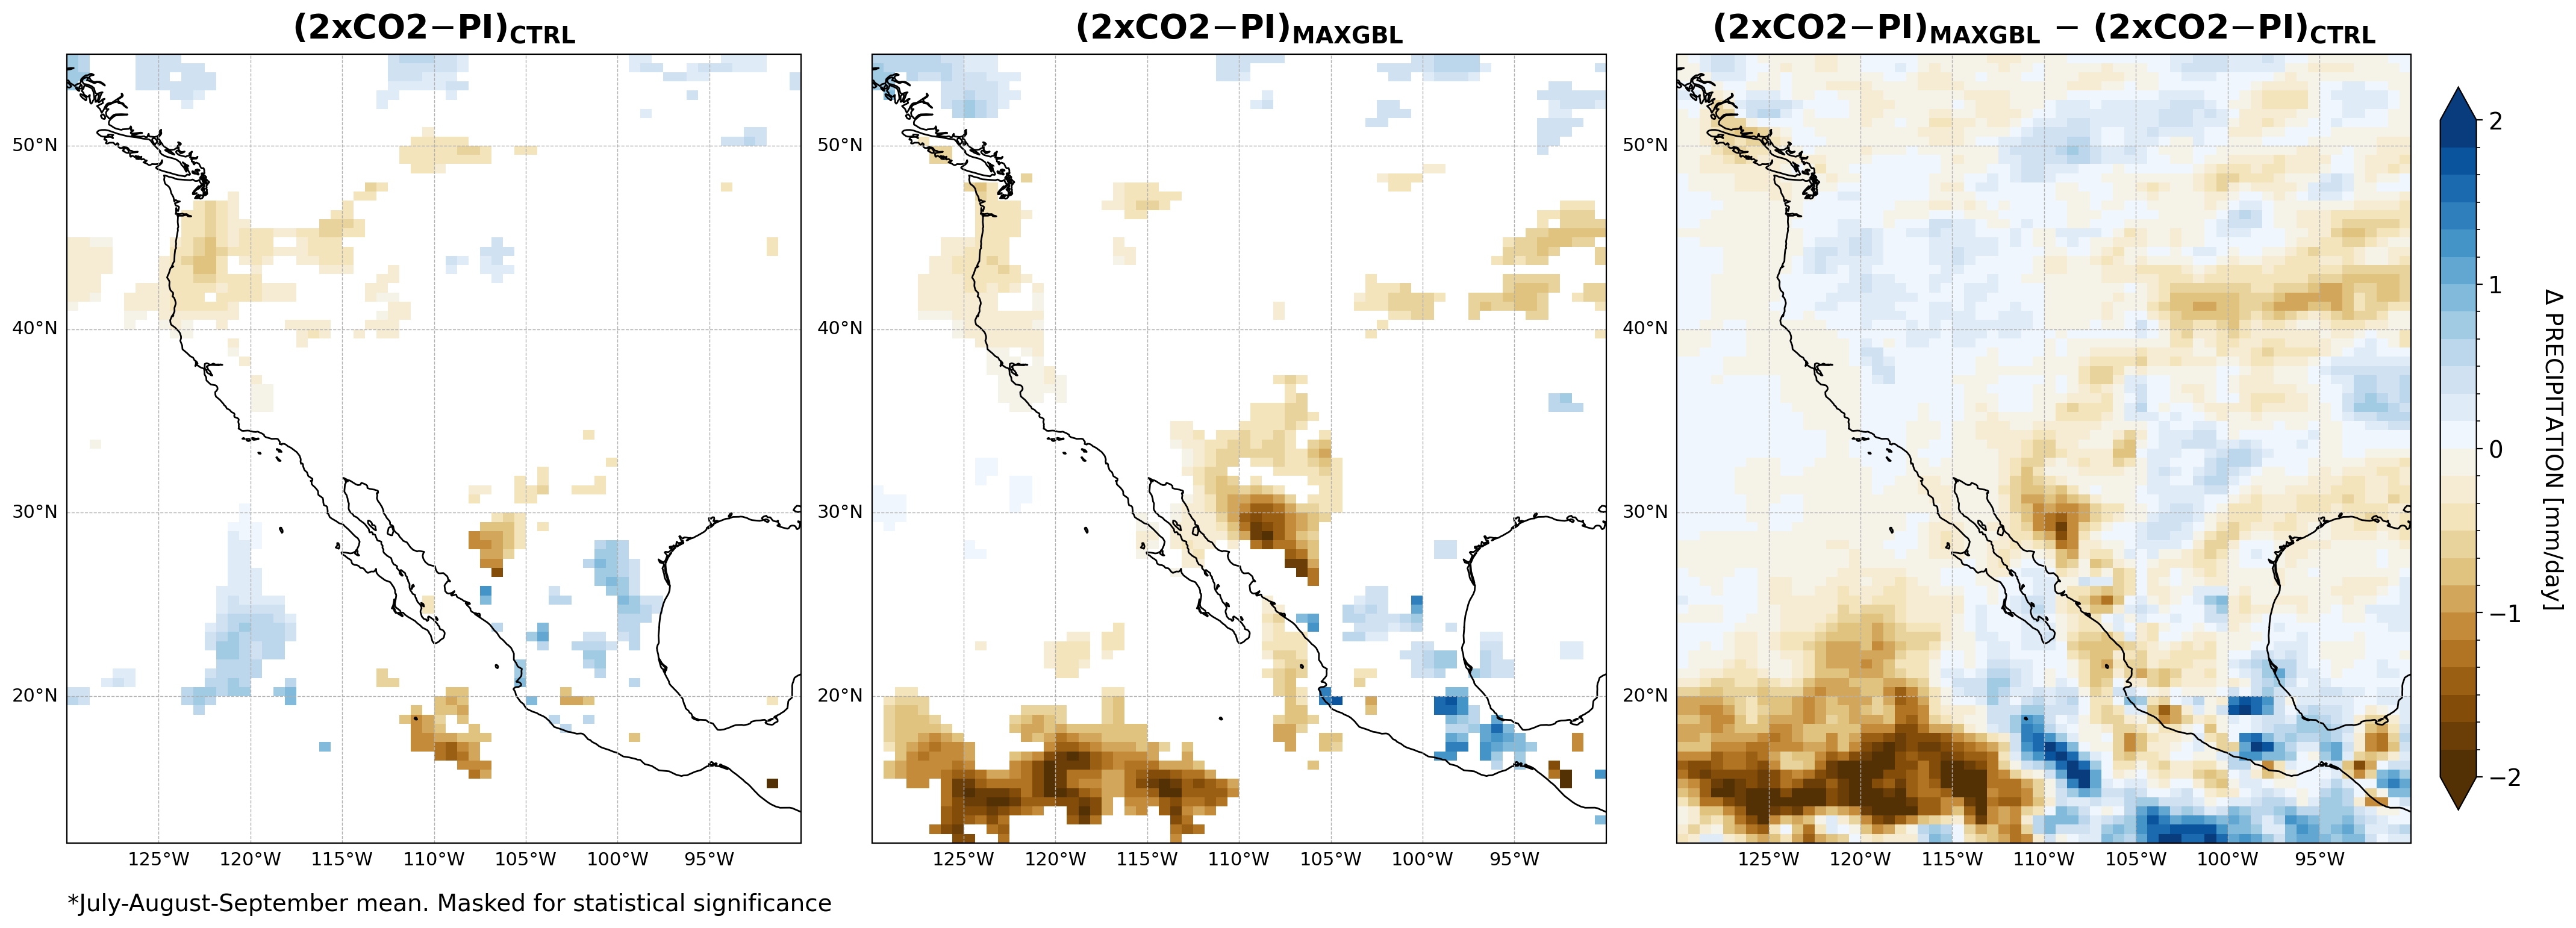

In [21]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':16, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
text_kw2={'color':'k', 'weight':'normal', 'size':14, 'horizontalalignment':'left', 'verticalalignment':'bottom'}
text_kw3={'color':'k', 'weight':'bold', 'size':20, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
titles=([r'(2xCO2$-$PI)$\mathbf{_{CTRL}}$',
         r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$',
         r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$ $-$ (2xCO2$-$PI)$\mathbf{_{CTRL}}$'])
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-2
dvmax=2
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[-130,-90,12,55]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,7.5), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'JAS Precipitation [FLOR]', **text_kw)
fig.text(0.025,-0.0175,
         '*July-August-September mean. '
         'Masked for statistical significance', **text_kw2)

future_diff_diff = future_diff['hitopo'] - future_diff['ctrl']
lon=future_diff_diff.lon
lat=future_diff_diff.lat

ax[0].pcolormesh(lon, lat, future_diff_mask['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)
ax[1].pcolormesh(lon, lat, future_diff_mask['hitopo'], cmap=dcmap, norm=dnorm, transform=trans)
cf2=ax[2].pcolormesh(lon, lat, (future_diff['hitopo']-future_diff['ctrl']), cmap=dcmap, norm=dnorm, transform=trans) 

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(-110, 55.5, titles[i], **text_kw3)
    # map properties
    ax.coastlines(color='k')
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':11}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':11}
    
cax=fig.add_axes([1.01, .1, 0.015, 0.8])
cbar=fig.colorbar(cf2, ticks=[-2,-1,0,1,2], orientation='vertical', extend='both', cax=cax)
cbar.set_label('$\Delta$ PRECIPITATION [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/precip.flor.2xco2.{season}.png', transparent=False, bbox_inches='tight')

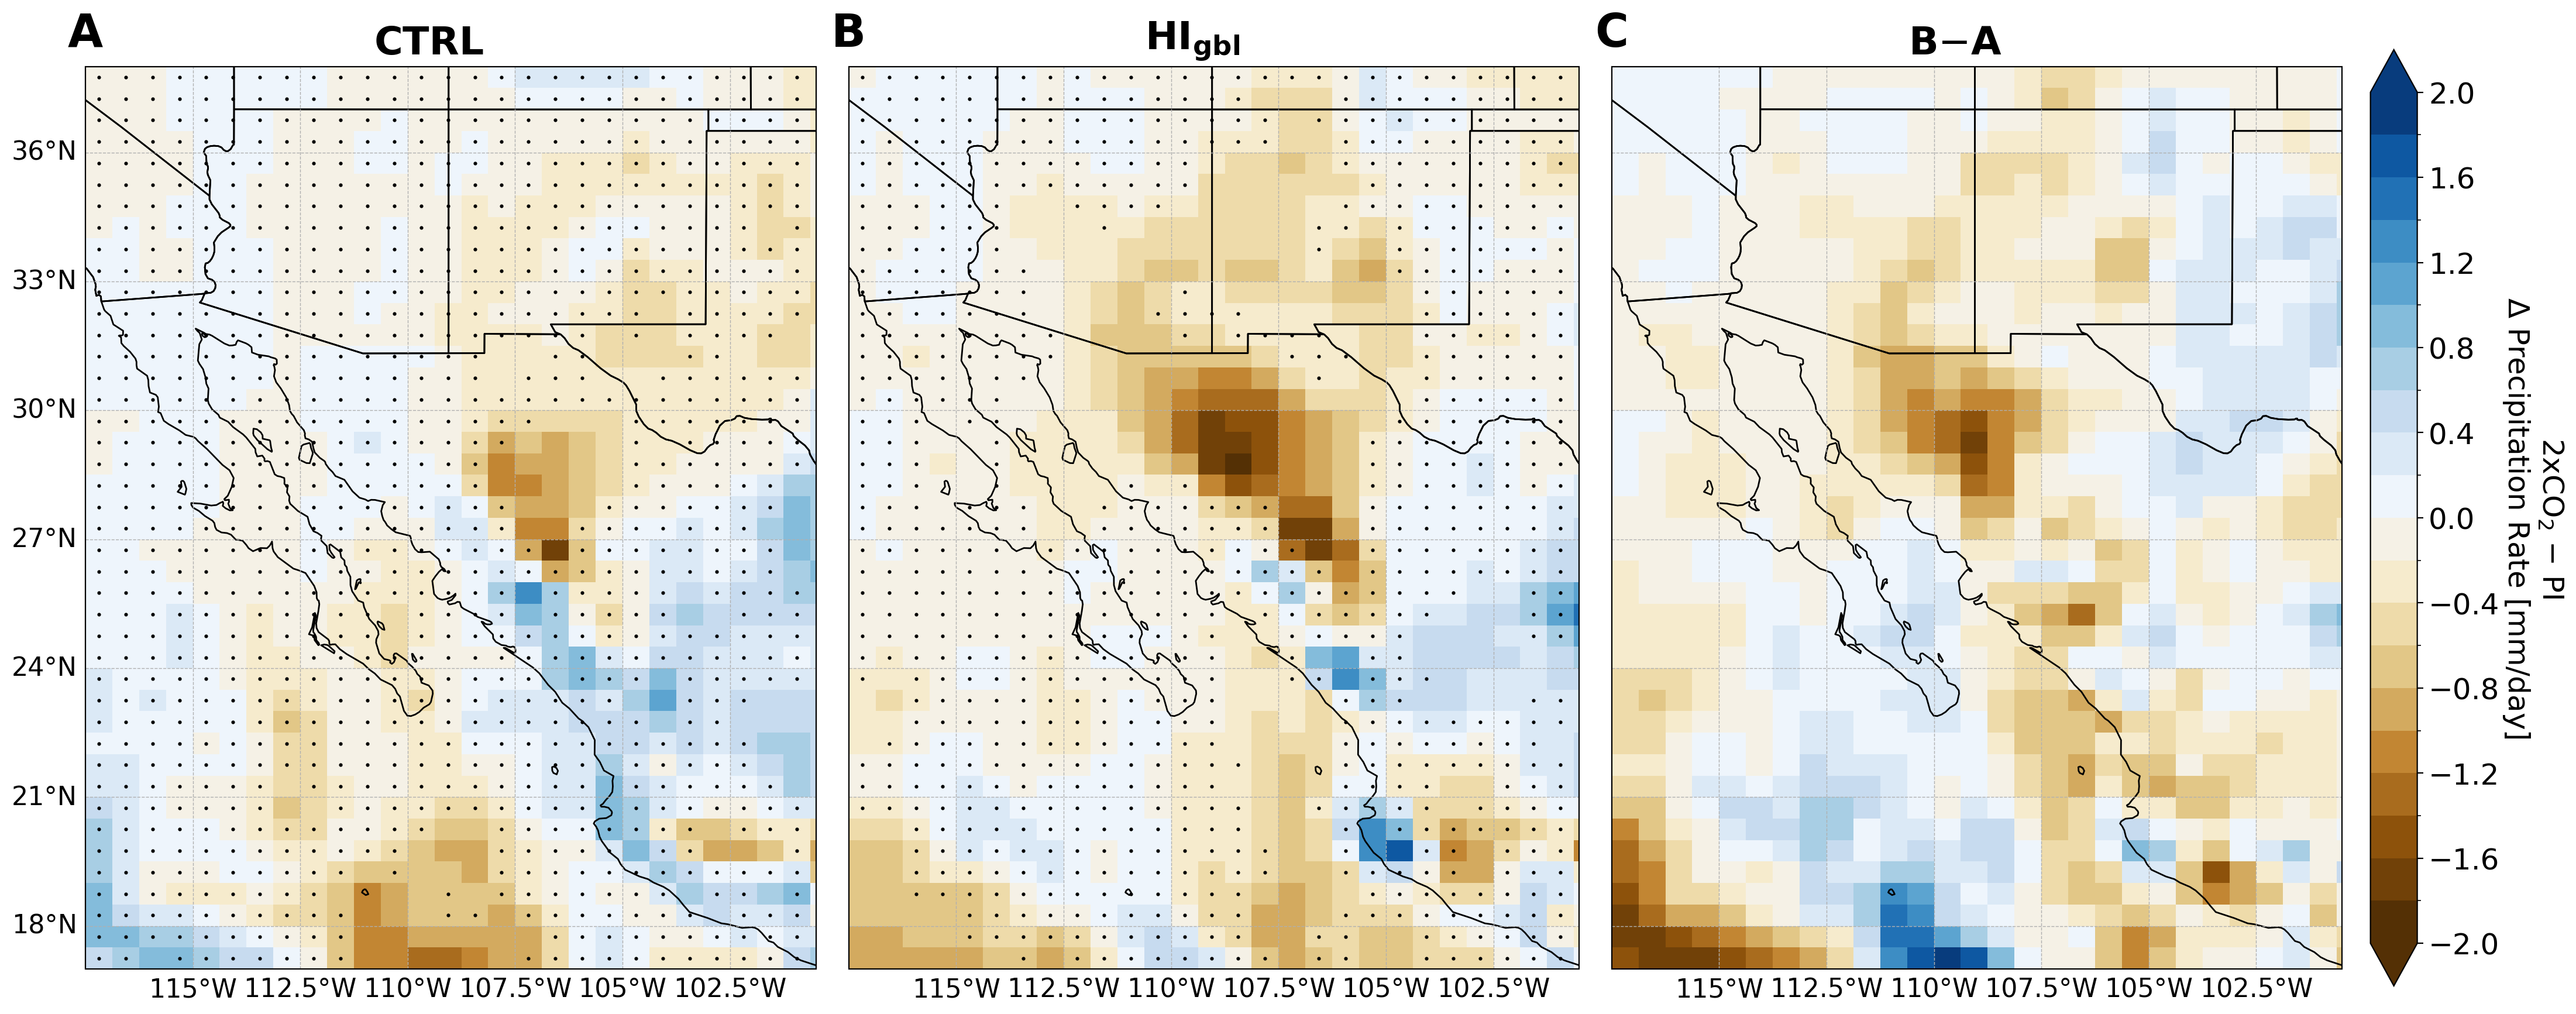

In [80]:
step=1
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':24, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
text_kw2={'color':'k', 'weight':'normal', 'size':14, 'horizontalalignment':'left', 'verticalalignment':'bottom'}
text_kw3={'color':'k', 'weight':'bold', 'size':28, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
titles=([r'CTRL',
         r'$\mathbf{HI_{gbl}}$',
         r'B$-$A'])
letters=['A','B','C','D']
tx=-109.5
ty=38.1
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-2
dvmax=2
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,4000,8)
# map specs
lon2d, lat2d = np.meshgrid(lon, lat)
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[242.5,259.5,17,38]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,10), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'JAS Precipitation [FLOR]', **text_kw)
"""
fig.text(0.025,-0.0175,
         'Percent change in July-August-September mean precipitation under 2xCO2 relative to JAS seasonal mean precip during the PI.\n'
         'A and B are masked for statistical significance, panel C is the difference between the masked percent changes in future precip.\n'
         'Data shown where the change in precip is significant for either simulation.', **text_kw2)
"""
lon=jas_mean['ctrl']['pi'].lon
lat=jas_mean['ctrl']['pi'].lat

# prec change
ax[0].pcolormesh(lon, lat, future_diff['ctrl'], cmap=dcmap, norm=dnorm, transform=trans)
ax[0].scatter( lon2d[future_diff_mask['ctrl'].mask == True][::step], lat2d[future_diff_mask['ctrl'].mask == True][::step],
              s=20, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )
ax[1].pcolormesh(lon, lat, future_diff['hitopo'], cmap=dcmap, norm=dnorm, transform=trans)
ax[1].scatter( lon2d[future_diff_mask['hitopo'].mask == True][::step], lat2d[future_diff_mask['hitopo'].mask == True][::step],
              s=20, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )
cf2=ax[2].pcolormesh(lon, lat, (future_diff['hitopo']-future_diff['ctrl']), cmap=dcmap, norm=dnorm, transform=trans) 

# topo contours
#ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[1].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[2].contour(lon, lat, topo['hitopo']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    #poly1=patches.Polygon(coords_map['north'], closed=True, ec='magenta', fc='none', lw=3, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-117.5, 38.25, letters[i], **text_kw3)
    # map properties
    ax.coastlines(color='k', lw=1)
    ax.set_extent(map_bnds, crs=trans)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    
cax=fig.add_axes([1.01, .1, 0.02, 0.8])
cbar=fig.colorbar(cf2, ticks=np.linspace(-2,2,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('2xCO$_2$ $-$ PI\n$\Delta$ Precipitation Rate [mm/day]', labelpad=40, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/precip.flor.2xco2.jas.png', transparent=False, bbox_inches='tight')
#plt.savefig(f'{opath}/precip.flor.2xco2.jas.pdf', transparent=False, bbox_inches='tight')

## FIGS: 2xCO2-PI change in JAS precipitation as percent of seasonal rainfall rate

In [12]:
ds1=(future_diff_mask['ctrl']/jas_mean['ctrl']['pi']) * 100
ds2=(future_diff_mask['hitopo']/jas_mean['hitopo']['pi']) * 100
future_diff_data = ds2.data-ds1.data

mask1 = np.ma.getmaskarray(future_diff_mask['ctrl'])
mask2 = np.ma.getmaskarray(future_diff_mask['hitopo'])
future_diff_mask = mask1 & mask2 # Mask only where BOTH are masked

future_diff_diff = np.ma.array(future_diff_data , mask=future_diff_mask)

future_diff_diff = np.ma.array(ds2.data-ds1.data, mask=np.ma.getmaskarray(ds1) & np.ma.getmaskarray(ds2))

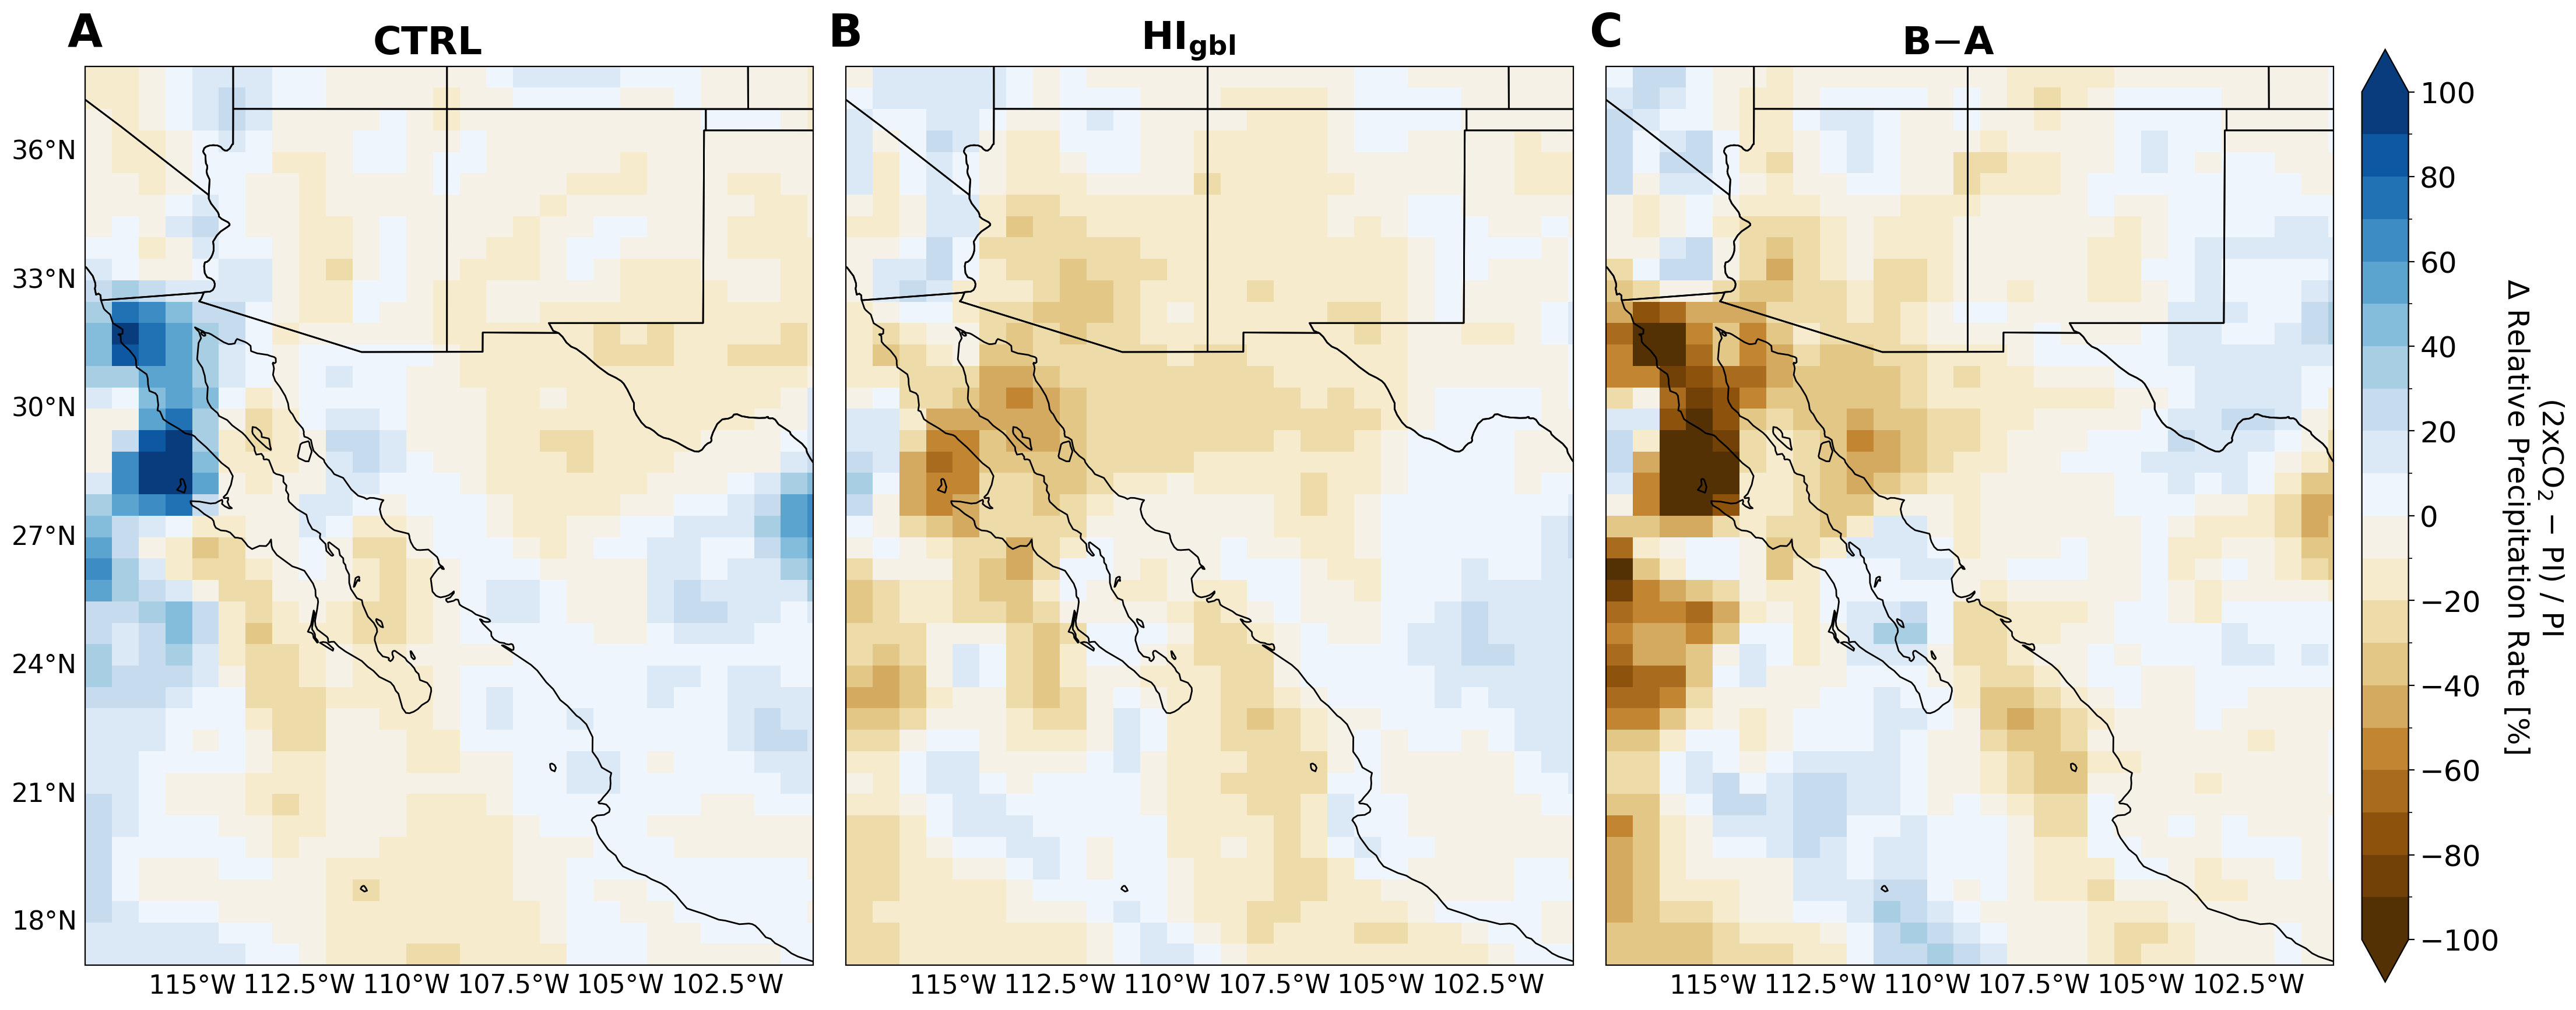

In [83]:
step=1
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':24, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
text_kw2={'color':'k', 'weight':'normal', 'size':14, 'horizontalalignment':'left', 'verticalalignment':'bottom'}
text_kw3={'color':'k', 'weight':'bold', 'size':28, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
titles=([r'CTRL',
         r'$\mathbf{HI_{gbl}}$',
         r'B$-$A'])
letters=['A','B','C','D']
tx=-109.5
ty=38.1
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-100
dvmax=100
dlevels=np.linspace(dvmin, dvmax, 21)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,4000,8)
# map specs
lon2d, lat2d = np.meshgrid(lon, lat)
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[242.5,259.5,17,38]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,10), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'JAS Precipitation [FLOR]', **text_kw)
"""
fig.text(0.025,-0.0175,
         'Percent change in July-August-September mean precipitation under 2xCO2 relative to JAS seasonal mean precip during the PI.\n'
         'A and B are masked for statistical significance, panel C is the difference between the masked percent changes in future precip.\n'
         'Data shown where the change in precip is significant for either simulation.', **text_kw2)
"""
lon=jas_mean['ctrl']['pi'].lon
lat=jas_mean['ctrl']['pi'].lat

# prec change
ds1 = (future_diff['ctrl']/jas_mean['ctrl']['pi']) * 100
ax[0].pcolormesh(lon, lat, ds1, cmap=dcmap, norm=dnorm, transform=trans)
#ax[0].scatter( lon2d[future_diff_mask['ctrl'].mask == True][::step], lat2d[future_diff_mask['ctrl'].mask == True][::step],
#              s=20, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )
ds2 = (future_diff['hitopo']/jas_mean['hitopo']['pi']) * 100
ax[1].pcolormesh(lon, lat, ds2, cmap=dcmap, norm=dnorm, transform=trans)
#ax[1].scatter( lon2d[future_diff_mask['hitopo'].mask == True][::step], lat2d[future_diff_mask['hitopo'].mask == True][::step],
#              s=20, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )

cf2=ax[2].pcolormesh(lon, lat, ds2-ds1, cmap=dcmap, norm=dnorm, transform=trans) 

# topo contours
#ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[1].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[2].contour(lon, lat, topo['hitopo']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    #poly1=patches.Polygon(coords_map['north'], closed=True, ec='magenta', fc='none', lw=3, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-117.5, 38.25, letters[i], **text_kw3)
    # map properties
    ax.coastlines(color='k', lw=1)
    ax.set_extent(map_bnds, crs=trans)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    
cax=fig.add_axes([1.01, .1, 0.02, 0.8])
cbar=fig.colorbar(cf2, ticks=np.linspace(-100,100,11), orientation='vertical', extend='both', cax=cax)
cbar.set_label('(2xCO$_2$ $-$ PI) / PI\n$\Delta$ Relative Precipitation Rate [%]', labelpad=40, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

#plt.savefig(f'{opath}/precip.flor.2xco2.jas.png', transparent=False, bbox_inches='tight')
#plt.savefig(f'{opath}/precip.flor.2xco2.jas.pdf', transparent=False, bbox_inches='tight')

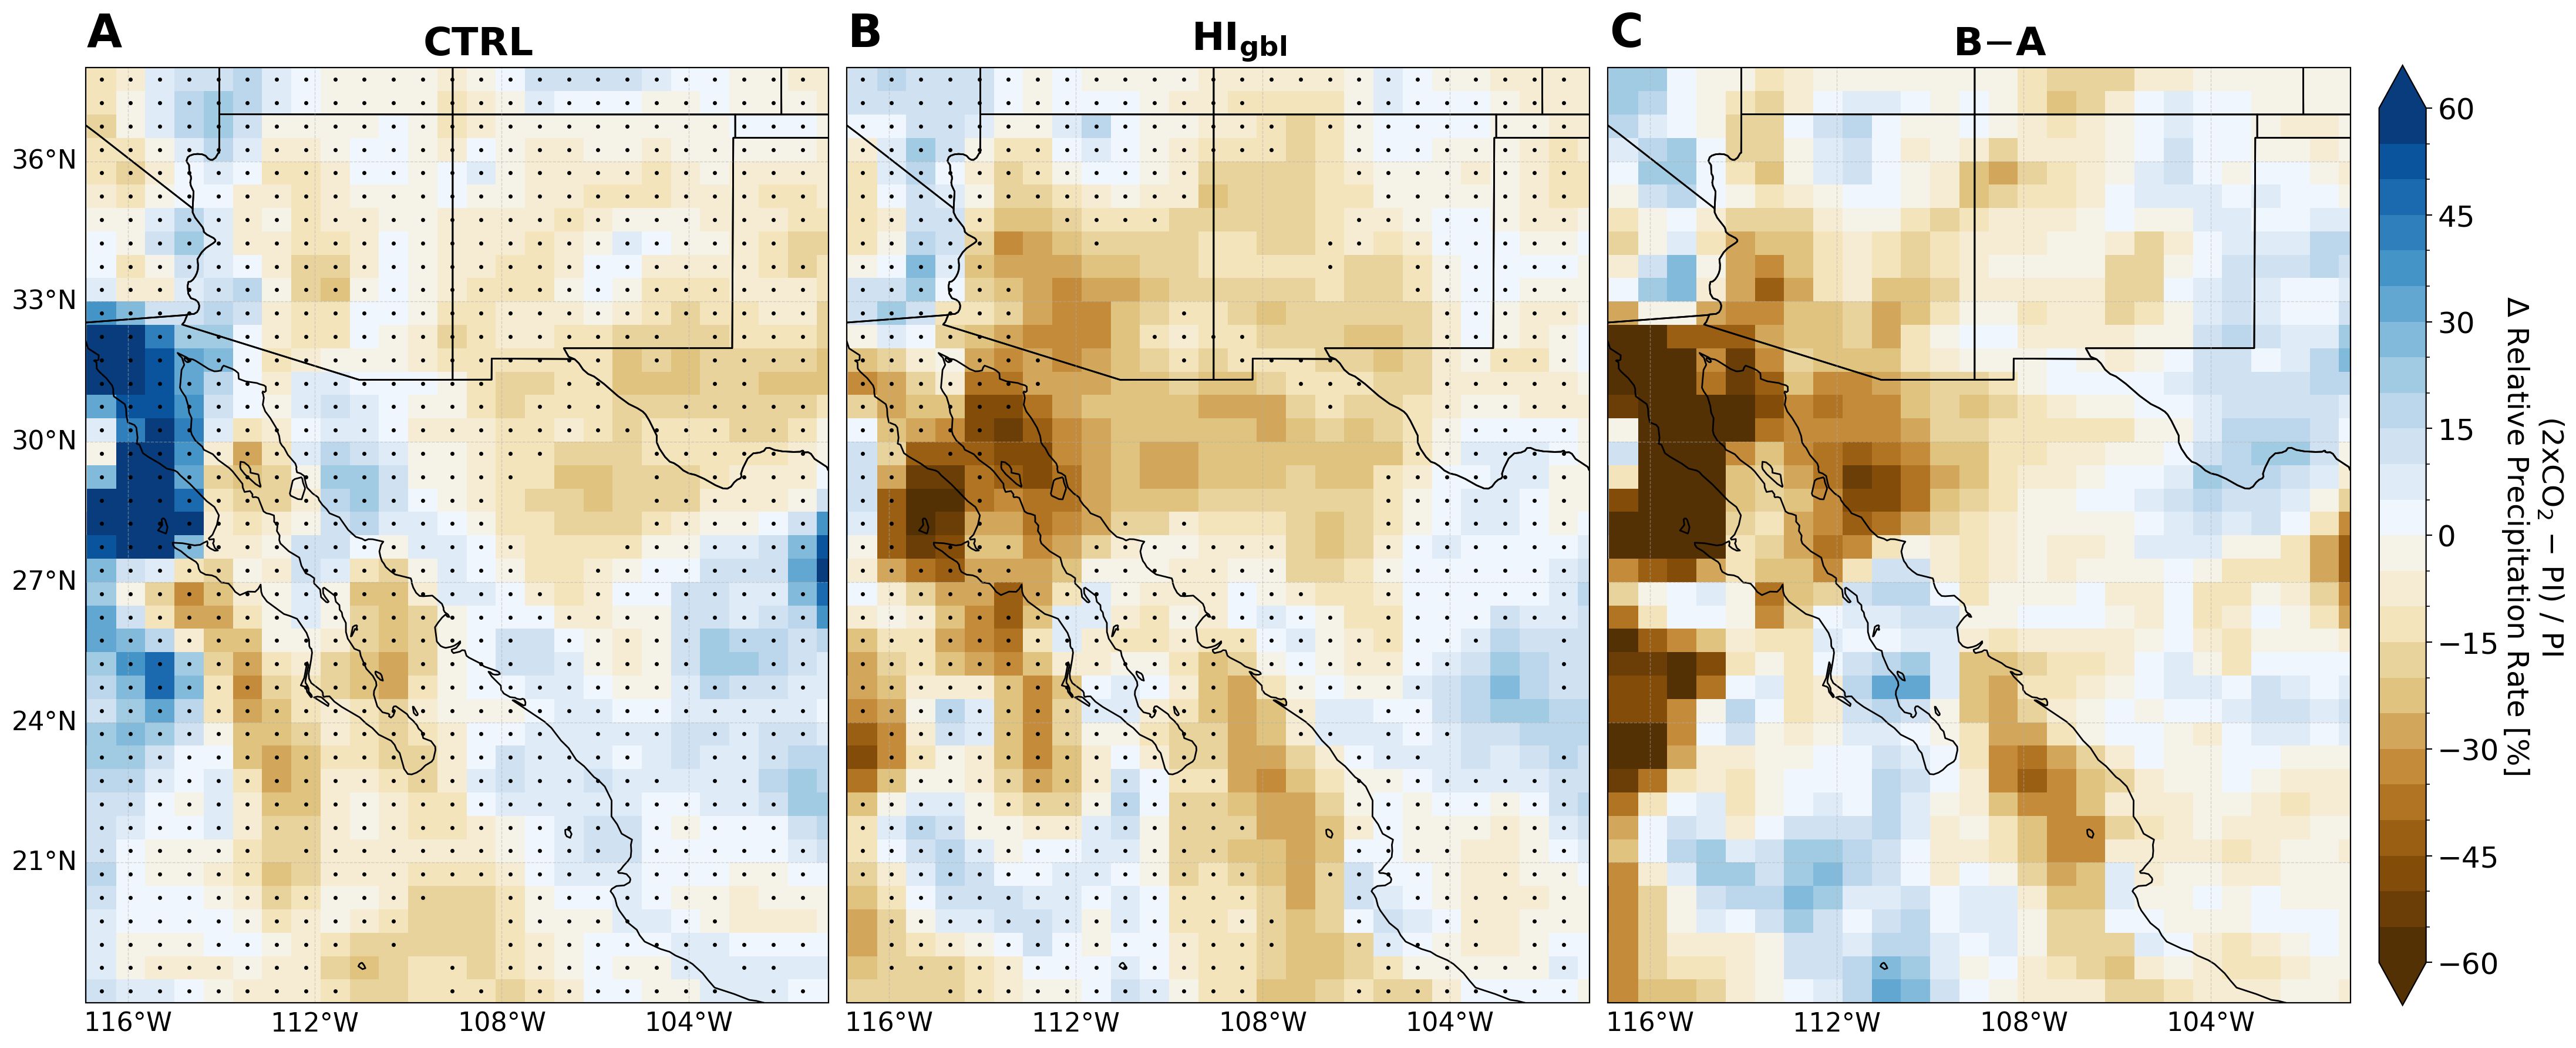

In [103]:
# -------------------- #
#       Settings       #
# -------------------- #
text_kw={'color':'k', 'weight':'bold', 'size':24, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
text_kw2={'color':'k', 'weight':'normal', 'size':14, 'horizontalalignment':'left', 'verticalalignment':'bottom'}
text_kw3={'color':'k', 'weight':'bold', 'size':28, 'horizontalalignment':'center', 'verticalalignment':'bottom'}
titles=([r'CTRL',
         r'$\mathbf{HI_{gbl}}$',
         r'B$-$A'])
letters=['A','B','C','D']
tx=-108.5
ty=38.1
step=1
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-60
dvmax=60
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# topography contours
zlevels=np.linspace(1000,4000,8)
# map specs
lon2d, lat2d = np.meshgrid(lon, lat)
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[243.1,259,18,38]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(20,10), layout='constrained', subplot_kw={'projection':proj})

#fig.text(.5,1.0,f'JAS Precipitation [FLOR]', **text_kw)
"""
fig.text(0.025,-0.0175,
         'Percent change in July-August-September mean precipitation under 2xCO2 relative to JAS seasonal mean precip during the PI.\n'
         'A and B are masked for statistical significance, panel C is the difference between the masked percent changes in future precip.\n'
         'Data shown where the change in precip is significant for either simulation.', **text_kw2)
"""
lon=jas_mean['ctrl']['pi'].lon
lat=jas_mean['ctrl']['pi'].lat

# prec change
ds1 = (future_diff['ctrl']/jas_mean['ctrl']['pi']) * 100
ds1_mask = ((future_diff_mask['ctrl']/jas_mean['ctrl']['pi']) * 100).mask
ax[0].pcolormesh(lon, lat, ds1, cmap=dcmap, norm=dnorm, transform=trans)
ax[0].scatter( lon2d[ds1_mask == True][::step], lat2d[ds1_mask == True][::step],
              s=25, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )
ds2 = (future_diff['hitopo']/jas_mean['hitopo']['pi']) * 100
ds2_mask = ((future_diff_mask['hitopo']/jas_mean['hitopo']['pi']) * 100).mask
ax[1].pcolormesh(lon, lat, ds2, cmap=dcmap, norm=dnorm, transform=trans)
ax[1].scatter( lon2d[ds2_mask == True][::step], lat2d[ds2_mask == True][::step],
              s=25, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )

cf2=ax[2].pcolormesh(lon, lat, ds2-ds1, cmap=dcmap, norm=dnorm, transform=trans) 
#ax[2].scatter( lon2d[ds2_mask == True][::step], lat2d[ds2_mask == True][::step],
#              s=25, c='k', marker='.', linewidths=0, transform=trans, zorder=100 )

# topo contours
#ax[0].contour(lon, lat, topo['ctrl'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[1].contour(lon, lat, topo['hitopo'], levels=zlevels, linewidths=1, colors='black', transform=trans)
#ax[2].contour(lon, lat, topo['hitopo']-topo['ctrl'], levels=np.linspace(500,1500,5), linewidths=1, colors='black', transform=trans)

for i, ax in enumerate(ax.flat): 
    #poly1=patches.Polygon(coords_map['north'], closed=True, ec='magenta', fc='none', lw=3, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax.add_patch(poly1)
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw)
    ax.text(-116.5, 38.25, letters[i], **text_kw3)
    # map properties
    ax.coastlines(color='k', lw=1)
    ax.set_extent(map_bnds, crs=trans)
    ax.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
    ax.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=0.5, linestyle='--', zorder=10, draw_labels=True)
    gl.xlocator = mticker.MultipleLocator(4)
    gl.ylocator = mticker.MultipleLocator(3)
    gl.bottom_labels=True; gl.left_labels=(i==0); gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':16}
    
cax=fig.add_axes([1.01, .1, 0.02, 0.8])
cbar=fig.colorbar(cf2, ticks=np.linspace(-60,60,9), orientation='vertical', extend='both', cax=cax)
cbar.set_label('(2xCO$_2$ $-$ PI) / PI\n$\Delta$ Relative Precipitation Rate [%]', labelpad=40, rotation=270, size=18, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=18)
for tick in cbar.ax.yaxis.get_major_ticks():
    tick.label2.set_fontweight('normal')

plt.savefig(f'figs/precip.flor.2xco2.jas.png', transparent=False, bbox_inches='tight')
plt.savefig(f'figs/precip.flor.2xco2.jas.pdf', transparent=False, bbox_inches='tight')

## FIGS: Precip climos and differences

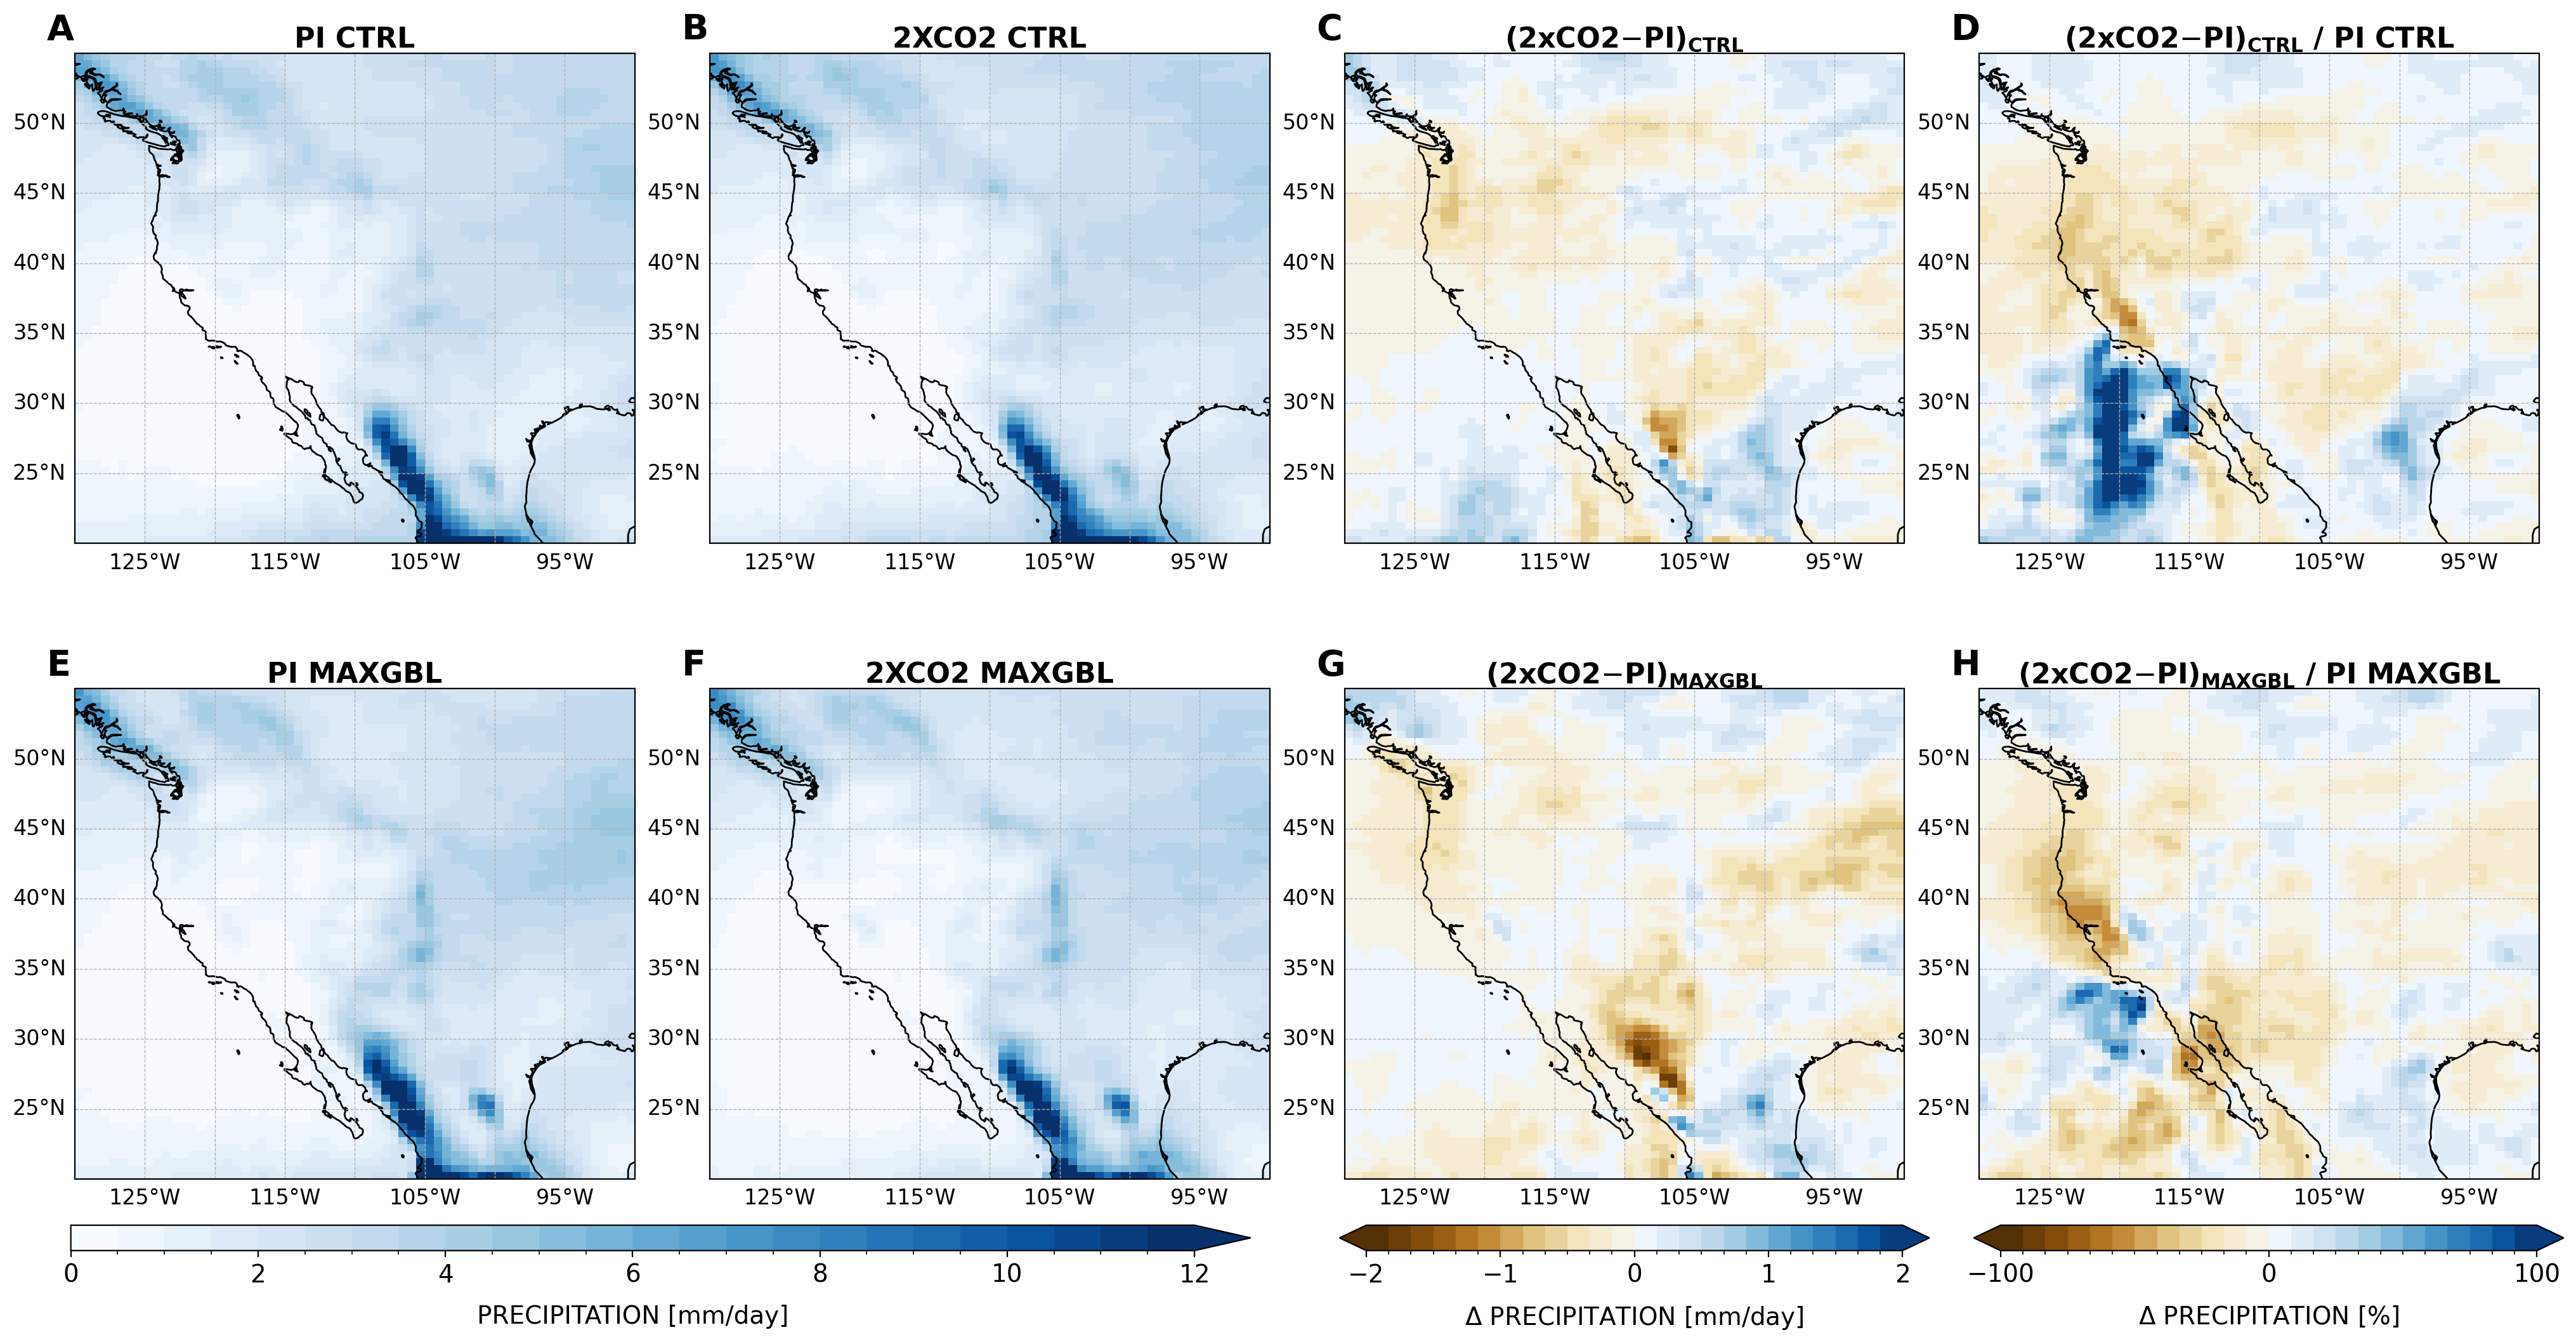

In [12]:
# -------------------- #
#       Settings       #
# -------------------- #
# plot specs
lw=1
text_kw={'color':  'k', 'weight': 'bold', 'size': 16, 'horizontalalignment': 'left', 'verticalalignment': 'bottom'}
text_kw2={'color':  'k', 'weight': 'bold', 'size': 24, 'horizontalalignment': 'center', 'verticalalignment': 'bottom'}
text_kw3={'color':  'k', 'weight': 'bold', 'size': 16, 'horizontalalignment': 'center', 'verticalalignment': 'bottom'}
titles=np.array(['PI CTRL', '2XCO2 CTRL', r'(2xCO2$-$PI)$\mathbf{_{CTRL}}$', r'(2xCO2$-$PI)$\mathbf{_{CTRL}}$ / PI CTRL',
                 'PI MAXGBL', '2XCO2 MAXGBL', r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$', r'(2xCO2$-$PI)$\mathbf{_{MAXGBL}}$ / PI MAXGBL'])
letters=['A','B','C','D','E','F','G','H','J','K','L','M','N','O','P']
tx=-110
ty=55
# climo colormap
cmap,_,_,_=get_settings(field='precip', diff=False)
vmin=0
vmax=12
levels=np.linspace(vmin, vmax, 25)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
plevels=np.linspace(5,20,5)
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-2
dvmax=2
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# % colormap
dvmin2=-100
dvmax2=100
dlevels2=np.linspace(dvmin2, dvmax2, 25)
dnorm2=mpl.colors.BoundaryNorm(dlevels2, dcmap.N)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[-130,-90,20,55]


# ------------------- #
#      Make Plot      #
# ------------------- #
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(20,10), layout='constrained', subplot_kw={'projection':proj})

# CTRL
for key in ['ctrl']:
    # climatologies
    for i,case in enumerate(cases):
        lon=dat[key][case].lon
        lat=dat[key][case].lat
        cf1=ax[0,i].pcolormesh(lon, lat, jas_mean[key][case], cmap=cmap, norm=norm, transform=trans) 
    # absolute difference
    cf2=ax[0,2].pcolormesh(lon, lat, future_diff[key], cmap=dcmap, norm=dnorm, transform=trans)
    # difference as a percent
    cf3=ax[0,3].pcolormesh(lon, lat, (future_diff[key]/jas_mean[key]['pi'])*100, cmap=dcmap, norm=dnorm2, transform=trans)

# MAX-GBL
for key in ['hitopo']:
    # climatologies
    for i,case in enumerate(cases):
        lon=dat[key][case].lon
        lat=dat[key][case].lat
        cf1=ax[1,i].pcolormesh(lon, lat, jas_mean[key][case], cmap=cmap, norm=norm, transform=trans) 
    # absolute difference
    ax[1,2].pcolormesh(lon, lat, future_diff[key], cmap=dcmap, norm=dnorm, transform=trans)
    # difference as a percent
    ax[1,3].pcolormesh(lon, lat, (future_diff[key]/jas_mean[key]['pi'])*100, cmap=dcmap, norm=dnorm2, transform=trans)

for i, ax in enumerate(ax.flat): 
    # subplot labels
    ax.text(tx, ty, titles[i], **text_kw3)
    ax.text(-132,ty+1,letters[i], weight='bold', size=20, zorder=100)
    # map properties
    ax.coastlines(color='k')
    ax.set_extent(map_bnds, crs=trans)
    gl=ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER
    gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style={'color': 'black', 'weight': 'normal', 'size':12}
    gl.ylabel_style={'color': 'black', 'weight': 'normal', 'size':12}

# add colorbar
cax=fig.add_axes([0.025, 0, 0.465, 0.02])
cbar=fig.colorbar(cf1, ticks=[0,2,4,6,8,10,12,14,16,18,20], orientation='horizontal', extend='max', cax=cax)
cbar.set_label('PRECIPITATION [mm/day]', labelpad=10, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)
    
cax=fig.add_axes([.525, 0, 0.2325, 0.02])
cbar=fig.colorbar(cf2, ticks=[-3,-2,-1,0,1,2,3], orientation='horizontal', extend='both', cax=cax)
cbar.set_label('$\Delta$ PRECIPITATION [mm/day]', labelpad=10, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)

cax=fig.add_axes([.775, 0, 0.2325, 0.02])
cbar=fig.colorbar(cf3, ticks=[-200,-100,0,100,200], orientation='horizontal', extend='both', cax=cax)
cbar.set_label('$\Delta$ PRECIPITATION [%]', labelpad=10, size=14, fontweight='normal', ha='center')
cbar.ax.tick_params(labelsize=14)

#plt.savefig(f'{opath}/precip.flor.2xco2.{season}.png', transparent=False, bbox_inches='tight')